# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [91]:
import pandas as pd
import sklearn
from  pandas.api.types import is_numeric_dtype
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import StandardScaler, OneHotEncoder


## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [92]:
auto_mpg = fetch_ucirepo(id=9) 
df = auto_mpg.data.original
df.head()

,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,mpg
0,"chevrolet,chevelle,malibu",8,307.0,130.0,3504,12.0,70,1,18.0
1,"buick,skylark,320",8,350.0,165.0,3693,11.5,70,1,15.0
2,"plymouth,satellite",8,318.0,150.0,3436,11.0,70,1,18.0
3,"amc,rebel,sst",8,304.0,150.0,3433,12.0,70,1,16.0
4,"ford,torino",8,302.0,140.0,3449,10.5,70,1,17.0


### Step 2.a Assign variables `X` to the features and `y` to the target

In [93]:
X = df.drop(columns=['mpg']) 
y = df['mpg']

### Step 2.b print the type of each

In [94]:
print(f"Type of X: {type(X)}")
print(f"Type of y: {type(y)}")

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [95]:
if is_numeric_dtype(y):
    target_type = "Numerical"
    ml_task = "Regression"
else:
    target_type = "Categorical"
    ml_task = "Classification"

print(f"Target type: {target_type}")
print(f"Machine Learning Task: {ml_task}")

Target type: Numerical
Machine Learning Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [96]:
print(f"X shape: {X.shape}") # (398, 7)
print(f"y shape: {y.shape}") # (398,)

X shape: (398, 8)
y shape: (398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [97]:
print(df.describe())

print(df['origin'].astype('category').describe())

        cylinders  displacement  horsepower       weight  acceleration  \
count  398.000000    398.000000  392.000000   398.000000    398.000000   
mean     5.454774    193.425879  104.469388  2970.424623     15.568090   
std      1.701004    104.269838   38.491160   846.841774      2.757689   
min      3.000000     68.000000   46.000000  1613.000000      8.000000   
25%      4.000000    104.250000   75.000000  2223.750000     13.825000   
50%      4.000000    148.500000   93.500000  2803.500000     15.500000   
75%      8.000000    262.000000  126.000000  3608.000000     17.175000   
max      8.000000    455.000000  230.000000  5140.000000     24.800000   

       model_year      origin         mpg  
count  398.000000  398.000000  398.000000  
mean    76.010050    1.572864   23.514573  
std      3.697627    0.802055    7.815984  
min     70.000000    1.000000    9.000000  
25%     73.000000    1.000000   17.500000  
50%     76.000000    1.000000   23.000000  
75%     79.000000    2.00

### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

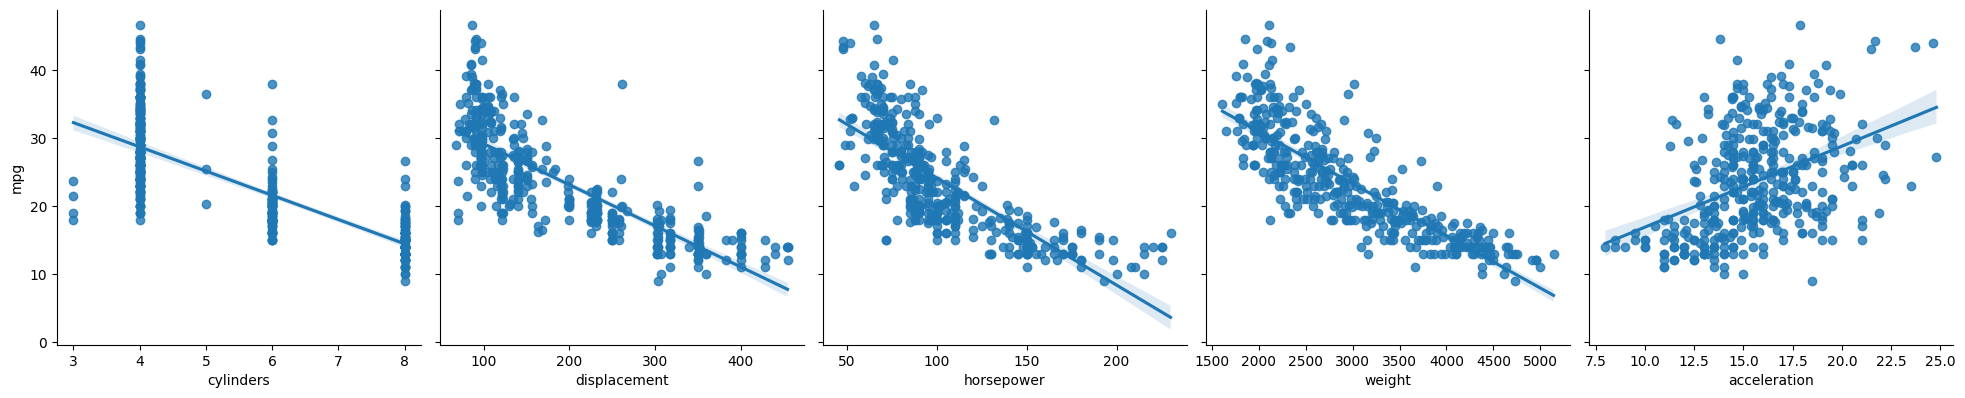

In [98]:
sns.pairplot(df, x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration'], 
             y_vars='mpg', height=4, aspect=1, kind='reg')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

In [99]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

for col in features:
    correlation = df[col].corr(df['mpg'])
    
    if correlation > 0:
        relationship = "Increasing (positive correlation) "
    elif correlation < 0:
        relationship = "Decreasing (negative correlation) "
    else:
        relationship = "No correlation "
    
    print(f"Feature: {col:10} | Relationship: {relationship} | Value: {correlation:.2f}")

Feature: cylinders  | Relationship: Decreasing (negative correlation)  | Value: -0.78
Feature: displacement | Relationship: Decreasing (negative correlation)  | Value: -0.80
Feature: horsepower | Relationship: Decreasing (negative correlation)  | Value: -0.78
Feature: weight     | Relationship: Decreasing (negative correlation)  | Value: -0.83
Feature: acceleration | Relationship: Increasing (positive correlation)  | Value: 0.42


### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [100]:
num_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
cat_features = ['origin']

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) # تحجيم البيانات
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', OneHotEncoder(), cat_features)
    ])


In [101]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


### Step 8. Split the dataset into train and test sets

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Fit the pipeline on the training set

In [103]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [104]:
model = pipe.named_steps['regressor']
print(f"Coefficients: {model.coef_}")
print(f"Intercept (Bias): {model.intercept_}")

Coefficients: [-0.27902384  2.03579258 -0.54483874 -5.91209471  0.18567473  2.97076221
 -1.87379677  1.07405901  0.79973776]
Intercept (Bias): 24.407969090592168


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [105]:
import numpy as np

numeric_transformer = pipe.named_steps["preprocessor"].named_transformers_["num"]
scaler = numeric_transformer.named_steps["scaler"]

num_features = ["displacement", "horsepower", "weight", "acceleration", "model year"]
weight_idx = num_features.index("weight")

weight_coef_scaled = pipe.named_steps["regressor"].coef_[weight_idx]
weight_coef_original = weight_coef_scaled / scaler.scale_[weight_idx]

kg_100_in_pounds = 220.46
mpg_gain = -kg_100_in_pounds * weight_coef_original

print(f"Weight coefficient in original units (mpg per pound): {weight_coef_original:.6f}")
print(f"Estimated mpg gain if weight decreases by 100 kg: {mpg_gain:.4f}")

Weight coefficient in original units (mpg per pound): -0.014712
Estimated mpg gain if weight decreases by 100 kg: 3.2434


### Step 10. Evaluate the pipeline on the test set

In [107]:
score = pipe.score(X_test, y_test)

print(f"R² score on test set: {score:.4f}")

R² score on test set: 0.8449
